In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv('heart_disease.csv')
display(data)

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,...,Yes,Medium,High,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes
9996,38.0,Male,172.0,154.0,Medium,No,No,No,31.856801,Yes,...,Yes,NaN,High,8.247784,Low,377.0,83.0,2.658267,9.715709,Yes
9997,73.0,Male,152.0,201.0,High,Yes,No,Yes,26.899911,No,...,Yes,NaN,Low,4.436762,Low,248.0,88.0,4.408867,9.492429,Yes
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,...,Yes,Medium,High,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes


In [3]:
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
numerical_cols.tolist()

['Age',
 'Blood Pressure',
 'Cholesterol Level',
 'BMI',
 'Sleep Hours',
 'Triglyceride Level',
 'Fasting Blood Sugar',
 'CRP Level',
 'Homocysteine Level']

In [4]:
print("\n--- ตรวจสอบความผิดปกติ (Sanity Check) ---")
display(data[numerical_cols].describe().T[['min', 'max', 'mean', 'std']])


--- ตรวจสอบความผิดปกติ (Sanity Check) ---


,min,max,mean,std
Age,18.000000,80.000000,49.296259,18.193970
Blood Pressure,120.000000,180.000000,149.757740,17.572969
Cholesterol Level,150.000000,300.000000,225.425577,43.575809
BMI,18.002837,39.996954,29.077269,6.307098
Sleep Hours,4.000605,9.999952,6.991329,1.753195
Triglyceride Level,100.000000,400.000000,250.734409,87.067226
Fasting Blood Sugar,80.000000,160.000000,120.142213,23.584011
CRP Level,0.003647,14.997087,7.472201,4.340248
Homocysteine Level,5.000236,19.999037,12.456271,4.323426


In [5]:
num_imputer = SimpleImputer(strategy='mean')
num_imputer

SimpleImputer()

In [6]:
data[numerical_cols] = num_imputer.fit_transform(data[numerical_cols])
data[numerical_cols].isnull().sum()

Age                    0
Blood Pressure         0
Cholesterol Level      0
BMI                    0
Sleep Hours            0
Triglyceride Level     0
Fasting Blood Sugar    0
CRP Level              0
Homocysteine Level     0
dtype: int64

In [7]:
cat_cols = data.select_dtypes(include=['object']).columns
cat_cols.tolist()

['Gender',
 'Exercise Habits',
 'Smoking',
 'Family Heart Disease',
 'Diabetes',
 'High Blood Pressure',
 'Low HDL Cholesterol',
 'High LDL Cholesterol',
 'Alcohol Consumption',
 'Stress Level',
 'Sugar Consumption',
 'Heart Disease Status']

In [8]:
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_imputer

SimpleImputer(strategy='most_frequent')

In [9]:
data[cat_cols] = cat_imputer.fit_transform(data[cat_cols])
data[cat_cols].isnull().sum()

Gender                  0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sugar Consumption       0
Heart Disease Status    0
dtype: int64

In [10]:
print(f"--- มีคอลัมน์ตัวหนังสือทั้งหมด {len(cat_cols)} คอลัมน์ ---\n")

for col in cat_cols:
    print(f"📌 Feature: {col}")
    print(data[col].unique())  # หรือใช้ .value_counts() ถ้าอยากเห็นจำนวน
    print("-" * 30)

--- มีคอลัมน์ตัวหนังสือทั้งหมด 12 คอลัมน์ ---

📌 Feature: Gender
['Male' 'Female']
------------------------------
📌 Feature: Exercise Habits
['High' 'Low' 'Medium']
------------------------------
📌 Feature: Smoking
['Yes' 'No']
------------------------------
📌 Feature: Family Heart Disease
['Yes' 'No']
------------------------------
📌 Feature: Diabetes
['No' 'Yes']
------------------------------
📌 Feature: High Blood Pressure
['Yes' 'No']
------------------------------
📌 Feature: Low HDL Cholesterol
['Yes' 'No']
------------------------------
📌 Feature: High LDL Cholesterol
['No' 'Yes']
------------------------------
📌 Feature: Alcohol Consumption
['High' 'Medium' 'Low']
------------------------------
📌 Feature: Stress Level
['Medium' 'High' 'Low']
------------------------------
📌 Feature: Sugar Consumption
['Medium' 'Low' 'High']
------------------------------
📌 Feature: Heart Disease Status
['No' 'Yes']
------------------------------


In [11]:
data_encoded = data.copy()

In [12]:
custom_mapping = {
    # กลุ่มที่มีลำดับ (Ordinal)
    'Low': 0,
    'Medium': 1,
    'High': 2,
    'None': 0,      # เผื่อมีค่า None
    
    # กลุ่ม 2 ทางเลือก (Binary)
    'Yes': 1,
    'No': 0,
    'Male': 1,
    'Female': 0
}

In [13]:
print(f"กำลังแปลงข้อมูลในคอลัมน์: {list(cat_cols)}\n")
for col in cat_cols:
    # ลองแปลงด้วย Mapping ที่เรากำหนดก่อน
    data_encoded[col] = data_encoded[col].map(custom_mapping)
    
    # เช็คว่ามีค่าไหนหลุด (เป็น NaN) หรือไม่?
    # (ถ้า map ไม่เจอคำศัพท์ใน dict มันจะเป็น NaN)
    if data_encoded[col].isnull().sum() > 0:
        print(f"⚠️ เตือน: คอลัมน์ '{col}' มีบางค่าไม่ตรงกับ Mapping (จะใช้ LabelEncoder ช่วยแทน)")
        
        # ถ้าหลุด ให้เติมค่าเดิมกลับไปก่อน แล้วใช้ LabelEncoder แปลงแทน
        data_encoded[col] = data[col] # เอาค่าเดิมกลับมา
        le = LabelEncoder()
        data_encoded[col] = le.fit_transform(data_encoded[col].astype(str))
    
    print(f"✅ แปลง '{col}' เรียบร้อยแล้ว")

กำลังแปลงข้อมูลในคอลัมน์: ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption', 'Heart Disease Status']

✅ แปลง 'Gender' เรียบร้อยแล้ว
✅ แปลง 'Exercise Habits' เรียบร้อยแล้ว
✅ แปลง 'Smoking' เรียบร้อยแล้ว
✅ แปลง 'Family Heart Disease' เรียบร้อยแล้ว
✅ แปลง 'Diabetes' เรียบร้อยแล้ว
✅ แปลง 'High Blood Pressure' เรียบร้อยแล้ว
✅ แปลง 'Low HDL Cholesterol' เรียบร้อยแล้ว
✅ แปลง 'High LDL Cholesterol' เรียบร้อยแล้ว
✅ แปลง 'Alcohol Consumption' เรียบร้อยแล้ว
✅ แปลง 'Stress Level' เรียบร้อยแล้ว
✅ แปลง 'Sugar Consumption' เรียบร้อยแล้ว
✅ แปลง 'Heart Disease Status' เรียบร้อยแล้ว


In [14]:
print("\n--- ผลลัพธ์หลังแปลง (ต้องเป็นตัวเลขทั้งหมด) ---")
display(data_encoded.head())
print("\n--- เช็ค Data Type ---")
data_encoded.info()


--- ผลลัพธ์หลังแปลง (ต้องเป็นตัวเลขทั้งหมด) ---


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,1,153.0,155.0,2,1,1,0,24.991591,1,...,0,2,1,7.633228,1,342.0,120.142213,12.969246,12.387250,0
1,69.0,0,146.0,286.0,2,0,1,1,25.221799,0,...,0,1,2,8.744034,1,133.0,157.000000,9.355389,19.298875,0
2,46.0,1,126.0,216.0,0,0,0,0,29.855447,0,...,1,0,0,4.440440,0,393.0,92.000000,12.709873,11.230926,0
3,32.0,0,122.0,293.0,2,1,1,0,24.130477,1,...,1,0,2,5.249405,2,293.0,94.000000,12.509046,5.961958,0
4,60.0,1,166.0,242.0,0,1,1,1,20.486289,1,...,0,0,2,7.030971,2,263.0,154.000000,10.381259,8.153887,0



--- เช็ค Data Type ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   10000 non-null  float64
 1   Gender                10000 non-null  int64  
 2   Blood Pressure        10000 non-null  float64
 3   Cholesterol Level     10000 non-null  float64
 4   Exercise Habits       10000 non-null  int64  
 5   Smoking               10000 non-null  int64  
 6   Family Heart Disease  10000 non-null  int64  
 7   Diabetes              10000 non-null  int64  
 8   BMI                   10000 non-null  float64
 9   High Blood Pressure   10000 non-null  int64  
 10  Low HDL Cholesterol   10000 non-null  int64  
 11  High LDL Cholesterol  10000 non-null  int64  
 12  Alcohol Consumption   10000 non-null  int64  
 13  Stress Level          10000 non-null  int64  
 14  Sleep Hours           10000 non-null  float64
 

In [15]:
print(f"--- มีคอลัมน์ตัวหนังสือทั้งหมด {len(cat_cols)} คอลัมน์ ---\n")

for col in cat_cols:
    print(f"📌 Feature: {col}")
    print(data_encoded[col].unique())  # หรือใช้ .value_counts() ถ้าอยากเห็นจำนวน
    print("-" * 30)

--- มีคอลัมน์ตัวหนังสือทั้งหมด 12 คอลัมน์ ---

📌 Feature: Gender
[1 0]
------------------------------
📌 Feature: Exercise Habits
[2 0 1]
------------------------------
📌 Feature: Smoking
[1 0]
------------------------------
📌 Feature: Family Heart Disease
[1 0]
------------------------------
📌 Feature: Diabetes
[0 1]
------------------------------
📌 Feature: High Blood Pressure
[1 0]
------------------------------
📌 Feature: Low HDL Cholesterol
[1 0]
------------------------------
📌 Feature: High LDL Cholesterol
[0 1]
------------------------------
📌 Feature: Alcohol Consumption
[2 1 0]
------------------------------
📌 Feature: Stress Level
[1 2 0]
------------------------------
📌 Feature: Sugar Consumption
[1 0 2]
------------------------------
📌 Feature: Heart Disease Status
[0 1]
------------------------------


In [16]:
# 1. เตรียมข้อมูลดิบ (X, y)
target_col = 'Heart Disease Status'
X = data_encoded.drop(target_col, axis=1)
y = data_encoded[target_col]

In [17]:
# ==========================================
# 🟢 ชุดที่ 1: แบ่ง 80:20 (Standard 80:20)
# ==========================================
print("--- กำลังประมวลผลชุดข้อมูล 80:20 ---")

# 1.1 แบ่งข้อมูล
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

--- กำลังประมวลผลชุดข้อมูล 80:20 ---


In [18]:
# 1.2 Scale ข้อมูล (เรียนรู้จาก Train 80% เท่านั้น)
scaler_80 = StandardScaler()
X_train_80_scaled = scaler_80.fit_transform(X_train_80)
X_test_20_scaled = scaler_80.transform(X_test_20) # ใช้ค่า Mean/SD เดิมแปลง Test

In [19]:
X_train = scaler_80.transform(X_train_80)
X_train

array([[-1.6624182 ,  1.00050013,  1.43695865, ...,  1.64318497,
        -0.38070829,  1.2802138 ],
       [-1.4975599 , -0.99950012, -1.51521007, ...,  0.07495351,
        -0.9854125 , -1.09906762],
       [-0.2336462 , -0.99950012,  0.47182657, ..., -0.47604674,
         1.3452419 ,  1.68998869],
       ...,
       [-0.2336462 ,  1.00050013, -0.55007799, ..., -1.06943162,
        -0.92779884, -1.01441486],
       [-0.50841004, -0.99950012,  1.60727608, ...,  0.49879985,
        -0.4794385 , -0.79732326],
       [ 0.42578704, -0.99950012, -1.57198255, ..., -0.73035454,
        -0.9467541 ,  1.50337501]])

In [20]:
# 1.3 แปลงกลับเป็น DataFrame
X_train_80 = pd.DataFrame(X_train_80_scaled, columns=X.columns)
X_test_20 = pd.DataFrame(X_test_20_scaled, columns=X.columns)

In [21]:
X_train_80

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
0,-1.662418,1.0005,1.436959,1.065168,1.208962,-1.034080,1.003506,-1.002503,-0.044409,0.986590,1.009546,-0.988813,-1.419699,-1.223186,1.341152,1.232178,-0.576304,1.643185,-0.380708,1.280214
1,-1.497560,-0.9995,-1.515210,-1.279257,1.208962,-1.034080,-0.996506,-1.002503,0.173958,-1.013592,1.009546,1.011314,0.008929,1.231470,0.000102,-1.205968,0.961287,0.074954,-0.985413,-1.099068
2,-0.233646,-0.9995,0.471827,-1.233288,-0.018566,0.967043,1.003506,0.997503,0.762484,0.986590,-0.990545,1.011314,0.008929,0.004142,1.118201,-1.205968,1.443219,-0.476047,1.345242,1.689989
3,-1.112891,1.0005,-0.379761,1.524859,-1.246095,0.967043,-0.996506,0.997503,-1.204843,-1.013592,1.009546,-0.988813,1.437557,1.231470,1.635615,0.013105,1.362897,-0.003788,-1.567248,0.073407
4,-0.178693,-0.9995,-0.833940,-0.038091,-1.246095,-1.034080,1.003506,-1.002503,-0.140952,-1.013592,-0.990545,1.011314,1.437557,1.231470,0.556985,1.232178,1.144880,1.219339,0.793701,1.333951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,-1.332702,-0.9995,0.187964,1.685750,-0.018566,0.967043,-0.996506,0.997503,1.694947,0.986590,1.009546,-0.988813,1.437557,1.231470,1.275695,0.013105,1.603862,1.388877,-0.445905,-0.213530
7996,-0.233646,-0.9995,-0.550078,-0.005325,-0.018566,-1.034080,-0.996506,0.997503,1.471768,-1.013592,1.009546,1.011314,0.008929,0.004142,-0.531351,0.013105,1.248151,1.516031,-0.058990,0.495663
7997,-0.233646,1.0005,-0.550078,-0.313906,-1.246095,0.967043,-0.996506,-1.002503,-1.039096,0.986590,-0.990545,1.011314,0.008929,1.231470,1.613306,0.013105,0.846541,-1.069432,-0.927799,-1.014415
7998,-0.508410,-0.9995,1.607276,1.295013,-0.018566,-1.034080,-0.996506,-1.002503,-0.111957,-1.013592,-0.990545,1.011314,1.437557,0.004142,-1.040052,1.232178,-1.104134,0.498800,-0.479439,-0.797323


In [22]:
# ==========================================
# 🔵 ชุดที่ 2: แบ่ง 90:10 (Split 90:10)
# ==========================================
print("\n--- กำลังประมวลผลชุดข้อมูล 90:10 ---")

# 2.1 แบ่งข้อมูล
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)


--- กำลังประมวลผลชุดข้อมูล 90:10 ---


In [23]:
# 2.2 Scale ข้อมูล (เรียนรู้จาก Train 90% เท่านั้น - สร้าง Scaler ตัวใหม่!)
scaler_90 = StandardScaler()
X_train_90_scaled = scaler_90.fit_transform(X_train_90)
X_test_10_scaled = scaler_90.transform(X_test_10)

In [24]:
# 2.3 แปลงกลับเป็น DataFrame
X_train_90 = pd.DataFrame(X_train_90_scaled, columns=X.columns)
X_test_10 = pd.DataFrame(X_test_10_scaled, columns=X.columns)

In [25]:
X_train_90

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
0,-0.289724,0.998668,-0.779934,-0.356516,1.211326,-1.033218,-0.994681,1.012523,-0.825412,-1.008929,0.999112,1.011398,1.444308,1.234155,-1.114622,-1.204171,1.505627,0.754065,0.200664,0.496829
1,-0.729079,-1.001334,1.609842,-1.206985,-1.241302,0.967850,-0.994681,1.012523,-0.108653,0.991150,0.999112,-0.988730,0.014929,-1.222961,-0.684668,-1.204171,-1.186045,1.305212,-0.480282,-0.229316
2,-1.058595,0.998668,-1.348928,-0.977129,1.211326,0.967850,1.005348,-0.987632,-1.205215,0.991150,-1.000889,-0.988730,0.014929,1.234155,-0.020423,0.014626,-0.219804,0.796461,1.638189,-0.139948
3,1.687372,0.998668,0.187356,-1.390870,-0.014988,-1.033218,-0.994681,-0.987632,0.137600,0.991150,0.999112,1.011398,0.014929,0.005597,-0.841466,-1.204171,-0.334833,-1.620108,-0.705019,1.498013
4,-1.168433,0.998668,0.983948,-0.563387,1.211326,-1.033218,1.005348,-0.987632,-0.423572,0.991150,-1.000889,1.011398,-1.414450,0.005597,-1.126689,1.233423,1.459616,-1.111356,-1.290641,0.083695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,1.632453,-1.001334,-0.836833,-0.034717,-0.014988,-1.033218,1.005348,-0.987632,1.521795,-1.008929,0.999112,1.011398,0.014929,0.005597,-0.572279,-1.204171,1.298576,0.923649,-1.687643,0.425157
8996,0.094711,-1.001334,-1.235129,-1.505799,1.211326,0.967850,1.005348,-0.987632,-0.612908,0.991150,0.999112,1.011398,-1.414450,-1.222961,-0.132068,0.014626,1.045512,1.432400,0.366204,1.013173
8997,-1.333191,-1.001334,0.130457,0.608881,1.211326,-1.033218,1.005348,-0.987632,-0.294138,0.991150,-1.000889,1.011398,0.014929,-1.222961,0.195343,-1.204171,-0.415353,1.093233,0.931737,1.156614
8998,-0.234805,-1.001334,-0.552336,-0.001949,-0.014988,-1.033218,-0.994681,1.012523,1.475190,-1.008929,0.999112,1.011398,0.014929,0.005597,-0.530117,0.014626,1.252564,1.517192,-0.060651,0.493220


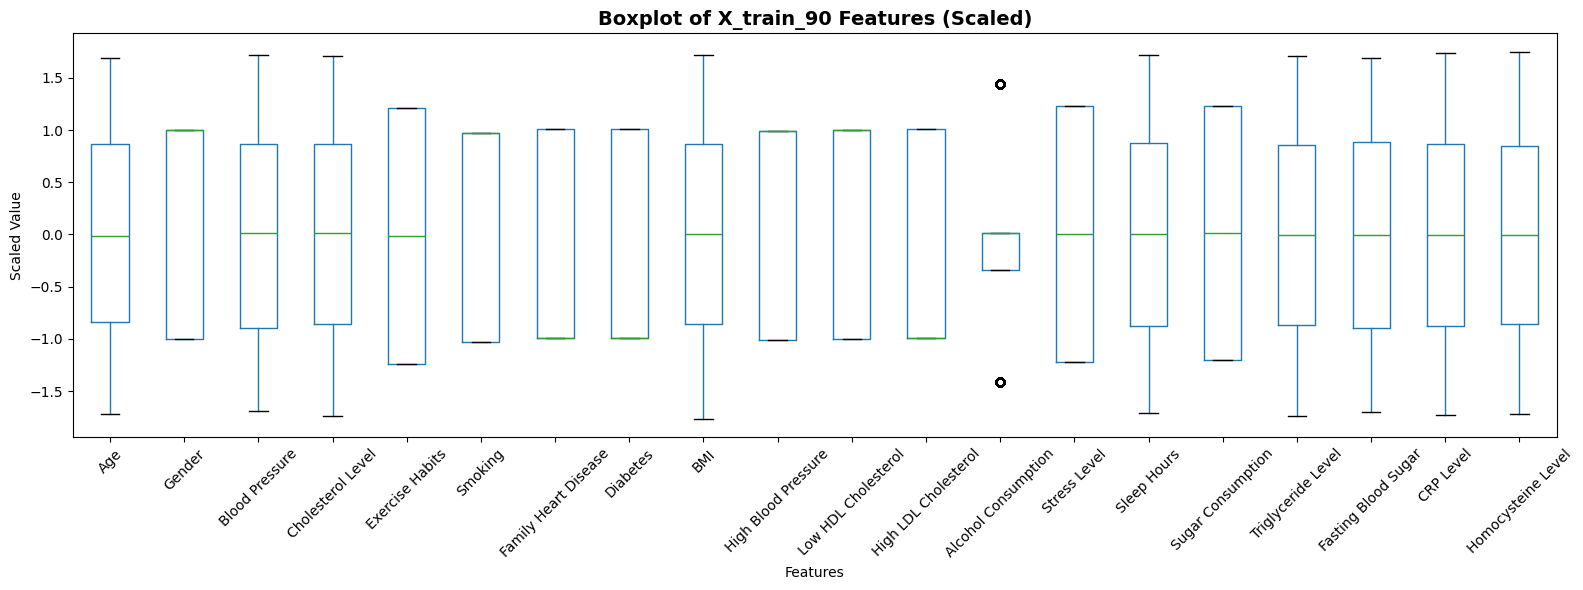

In [27]:
# แสดง Boxplot เพื่อดูช่วงค่าและ Outliers
plt.figure(figsize=(16, 6))
X_train_90.boxplot(rot=45, grid=False)
plt.title('Boxplot of X_train_90 Features (Scaled)', fontsize=14, fontweight='bold')
plt.ylabel('Scaled Value')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

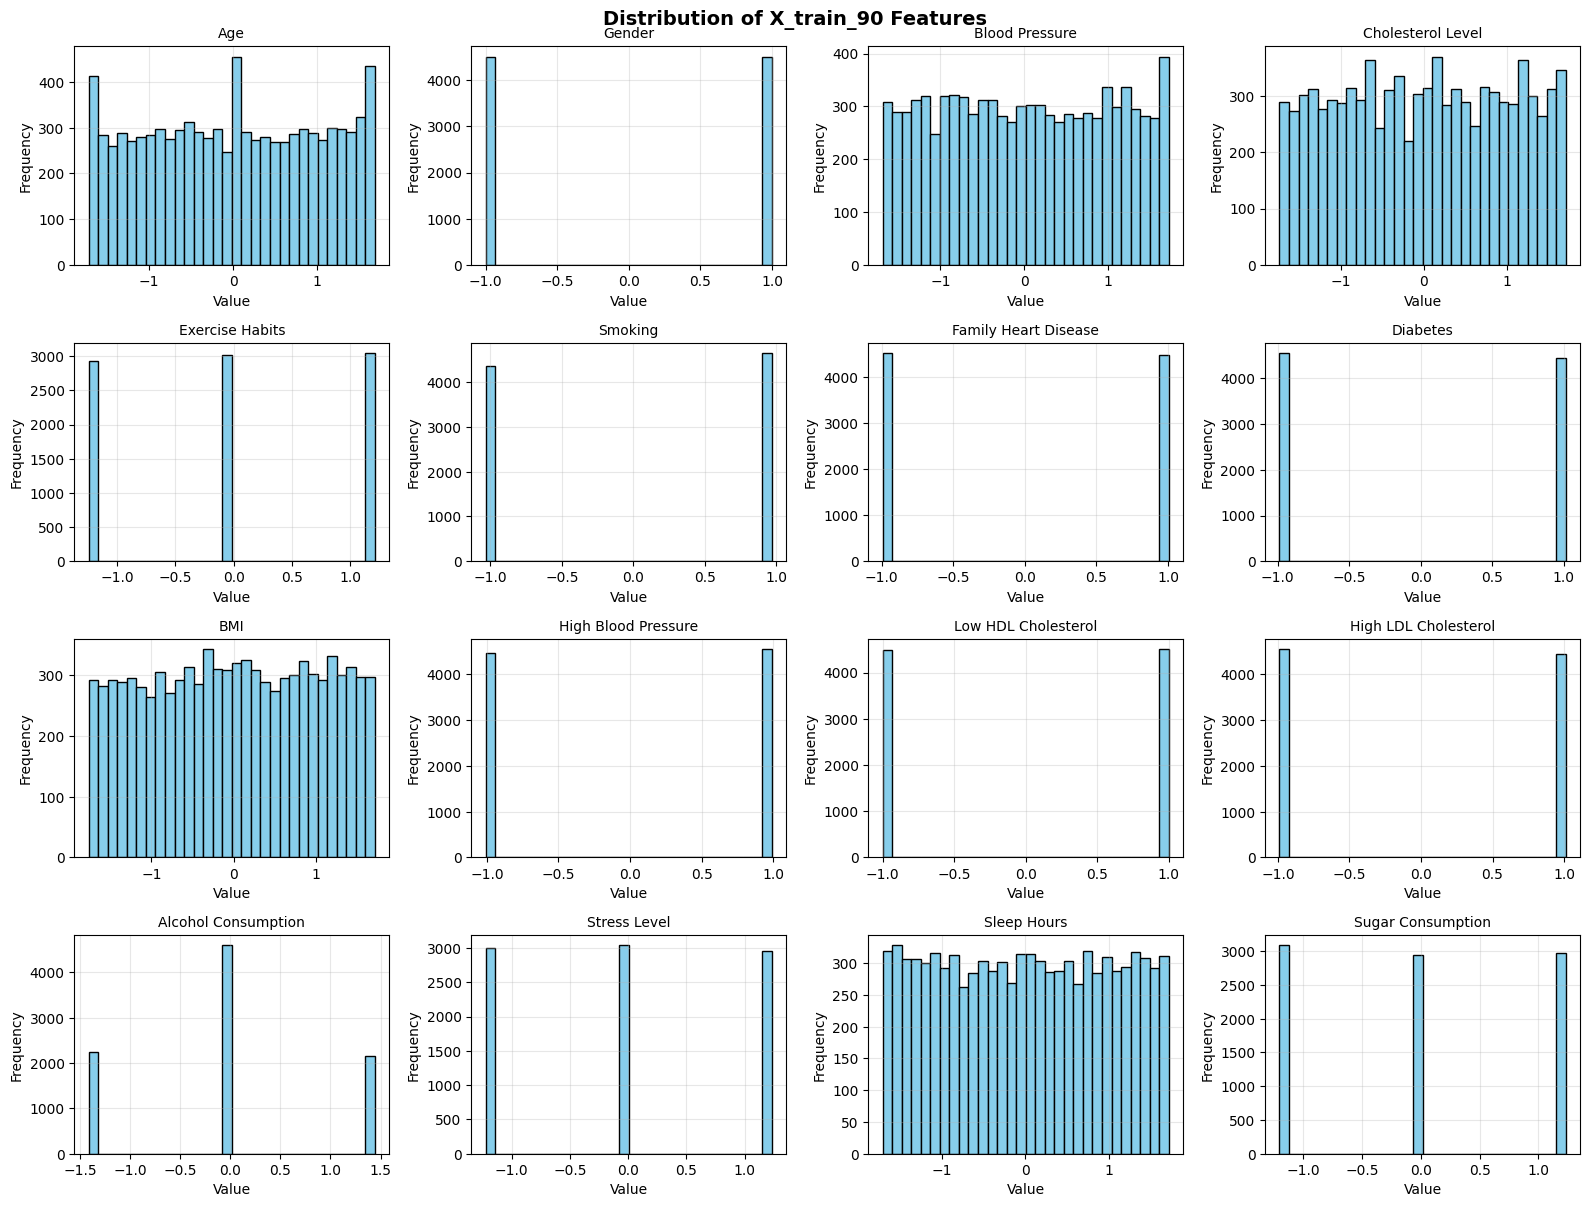

In [28]:
# แสดงกราฟ Histogram ของทุกฟีเจอร์ใน X_train_90
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(X_train_90.columns):
    if i < len(axes):
        axes[i].hist(X_train_90[col], bins=30, color='skyblue', edgecolor='black')
        axes[i].set_title(f'{col}', fontsize=10)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(alpha=0.3)

# ซ่อน subplot ที่ไม่ได้ใช้
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Distribution of X_train_90 Features', y=1.002, fontsize=14, fontweight='bold')
plt.show()

In [29]:
# ดูสถิติของ X_train_90
print("--- สถิติของ X_train_90 ---")
display(X_train_90.describe())

--- สถิติของ X_train_90 ---


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03,9.000000e+03
mean,1.693460e-16,-1.239502e-16,-7.583070e-16,9.118632e-17,1.894781e-16,3.039544e-17,-6.394885e-17,-5.052748e-17,2.159260e-16,-1.160553e-16,-3.710612e-17,5.131698e-17,6.552783e-17,2.368476e-18,-8.368614e-17,4.223782e-17,1.886886e-16,-2.253999e-16,-8.901521e-17,-2.431635e-16
std,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00
min,-1.717627e+00,-1.001334e+00,-1.690325e+00,-1.735655e+00,-1.241302e+00,-1.033218e+00,-9.946808e-01,-9.876320e-01,-1.764153e+00,-1.008929e+00,-1.000889e+00,-9.887302e-01,-1.414450e+00,-1.222961e+00,-1.709002e+00,-1.204171e+00,-1.738183e+00,-1.704900e+00,-1.730031e+00,-1.722241e+00
25%,-8.389173e-01,-1.001334e+00,-8.937327e-01,-8.622005e-01,-1.241302e+00,-1.033218e+00,-9.946808e-01,-9.876320e-01,-8.546343e-01,-1.008929e+00,-1.000889e+00,-9.887302e-01,-3.424157e-01,-1.222961e+00,-8.804787e-01,-1.204171e+00,-8.639648e-01,-8.993767e-01,-8.735480e-01,-8.617348e-01
50%,-1.512722e-02,9.986676e-01,1.665810e-02,1.125405e-02,-1.498828e-02,9.678499e-01,-9.946808e-01,-9.876320e-01,1.189417e-03,9.911503e-01,9.991115e-01,-9.887302e-01,1.492907e-02,5.596764e-03,3.514961e-03,1.462556e-02,-4.304216e-03,-9.061907e-03,-1.934421e-03,-7.404637e-03
75%,8.635822e-01,9.986676e-01,8.701495e-01,8.617229e-01,1.211326e+00,9.678499e-01,1.005348e+00,1.012523e+00,8.679262e-01,9.911503e-01,9.991115e-01,1.011398e+00,1.492907e-02,1.234155e+00,8.752401e-01,1.233423e+00,8.614664e-01,8.812529e-01,8.697848e-01,8.482760e-01
max,1.687372e+00,9.986676e-01,1.723641e+00,1.712192e+00,1.211326e+00,9.678499e-01,1.005348e+00,1.012523e+00,1.722686e+00,9.911503e-01,9.991115e-01,1.011398e+00,1.444308e+00,1.234155e+00,1.721991e+00,1.233423e+00,1.712679e+00,1.686776e+00,1.739197e+00,1.750744e+00


In [26]:
import os
os.makedirs('Data_Split', exist_ok=True) # สร้างโฟลเดอร์เก็บแยกไว้

# Save Set 1 (80:20)
X_train_80.to_csv('Data_Split/X_train_80.csv', index=False)
X_test_20.to_csv('Data_Split/X_test_20.csv', index=False)
y_train_80.to_csv('Data_Split/y_train_80.csv', index=False)
y_test_20.to_csv('Data_Split/y_test_20.csv', index=False)

# Save Set 2 (90:10)
X_train_90.to_csv('Data_Split/X_train_90.csv', index=False)
X_test_10.to_csv('Data_Split/X_test_10.csv', index=False)
y_train_90.to_csv('Data_Split/y_train_90.csv', index=False)
y_test_10.to_csv('Data_Split/y_test_10.csv', index=False)

print("\n✅ เสร็จเรียบร้อย! ข้อมูลถูกแบ่งและ Scale แยกกันอย่างถูกต้องแล้วครับ")
print("ไฟล์ถูกบันทึกไว้ในโฟลเดอร์ 'Data_Split'")


✅ เสร็จเรียบร้อย! ข้อมูลถูกแบ่งและ Scale แยกกันอย่างถูกต้องแล้วครับ
ไฟล์ถูกบันทึกไว้ในโฟลเดอร์ 'Data_Split'
